In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter

# from sklearn.model_selection import train_test_split
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

DATA_PATH = "../data/Obesity.csv"

## 1- Dataframe

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df.head(5)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
df.shape

(2111, 17)

In [6]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [8]:
def summary(df: pd.DataFrame) -> pd.DataFrame:
     return pd.DataFrame({
         "tipo": df.dtypes,
         "n_unicos": df.nunique(),
         "valores_unicos": [df[col].unique() for col in df.columns]
     })

summary(df)

,tipo,n_unicos,valores_unicos
Gender,object,2,"[Female, Male]"
Age,float64,1402,"[21.0, 23.0, 27.0, 22.0, 29.0, 24.0, 26.0, 41...."
Height,float64,1574,"[1.62, 1.52, 1.8, 1.78, 1.5, 1.64, 1.72, 1.85,..."
Weight,float64,1525,"[64.0, 56.0, 77.0, 87.0, 89.8, 53.0, 55.0, 68...."
family_history,object,2,"[yes, no]"
FAVC,object,2,"[no, yes]"
FCVC,float64,810,"[2.0, 3.0, 1.0, 2.450218, 2.880161, 2.00876, 2..."
NCP,float64,635,"[3.0, 1.0, 4.0, 3.28926, 3.995147, 1.72626, 2...."
CAEC,object,4,"[Sometimes, Frequently, Always, no]"
SMOKE,object,2,"[no, yes]"


In [9]:
for c in ["FCVC", "NCP", "CH2O", "FAF", "TUE", "Age"]:
    df[c] = np.rint(df[c]).astype(int)

df["FCVC"] = df["FCVC"].clip(1, 3)
df["NCP"]  = df["NCP"].clip(1, 4)
df["CH2O"] = df["CH2O"].clip(1, 3)
df["FAF"]  = df["FAF"].clip(0, 3)
df["TUE"]  = df["TUE"].clip(0, 2)

summary(df)

,tipo,n_unicos,valores_unicos
Gender,object,2,"[Female, Male]"
Age,int64,40,"[21, 23, 27, 22, 29, 24, 26, 41, 30, 52, 20, 1..."
Height,float64,1574,"[1.62, 1.52, 1.8, 1.78, 1.5, 1.64, 1.72, 1.85,..."
Weight,float64,1525,"[64.0, 56.0, 77.0, 87.0, 89.8, 53.0, 55.0, 68...."
family_history,object,2,"[yes, no]"
FAVC,object,2,"[no, yes]"
FCVC,int64,3,"[2, 3, 1]"
NCP,int64,4,"[3, 1, 4, 2]"
CAEC,object,4,"[Sometimes, Frequently, Always, no]"
SMOKE,object,2,"[no, yes]"


In [10]:
# Alvo binário
obese_classes = {"Obesity_Type_I","Obesity_Type_II","Obesity_Type_III"}
df["obeso"] = df["Obesity"].isin(obese_classes).astype(int)

In [11]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,obeso
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,0
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,0
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,0
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,0
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,0


## 2- Plots

In [12]:
def build_plot(df: pd.DataFrame, groupby: str, column: str, title: str, xlabel: str, ylabel: str):
    plt.figure()

    ax = df.groupby(groupby)[column].mean().plot(kind="bar")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    plt.xticks(rotation=45, ha="right")

    for p in ax.patches:
        value = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            value,
            f"{value*100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()
    

### Correlação

Resumo:
- Não foi encontrado variável isolada com associação forte ou direta com obesidade, sendo em grande parte fracos ou moderados
- Isso me sugere que a obesidade pode vir de uma combinação de múltiplos fatores ==> precisarei validar com mais calma, criando uma engenharia de atributos

Destaques quando o foco é a variável **obeso** (Pearson e Spearman):
- Nenhuma variável passou de 0.3
- **FAVC_ord** => indica que consumo frequente de alimentos calóricos aumenta obesidade, porém a correlação ainda não é muito alta
- **Age:** => fator gradual da idade auxilia para a tentência a obesidade, porém não é determinante
- **CAEC_ord**, **SCC_ord** e **FAF** mostraram correlações negativas

Outros destaques:
- CAEC e SCC:
  - Ficar de olho em variáveis como CAEC e SCC, que apresentaram correlações negativas para obesos. É possivel que sejam provenientes de comportamentos reativos de indivíduos já obesos -> ou seja, eles diminuiram o consumo de comida entre as refeições e/ou começaram a monitorar mais a injestão calórica.
- FAF x Age: -0.20
  - Conforme a idade aumenta, a frequência de atividade física tende a diminuir
  - Idade pode afetar obesidade indiretamente via redução de atividade física
- FAF x TUE: +0.06
  - Atividade física e tempo de tela são quase independentes
  - Ou seja, uma pessoa pode treinar bastante e ainda passar muito tempo em tela
  - É preciso achar uma fórmula para calcular o sedentarismo na engenharia de atributos
- FAVC_ord × CAEC_ord: −0.15 a −0.16
  - Indivíduos que consomem muitos alimentos calóricos não necessariamente comem entre as refeições
  - As calorias podem vir das refeições principais

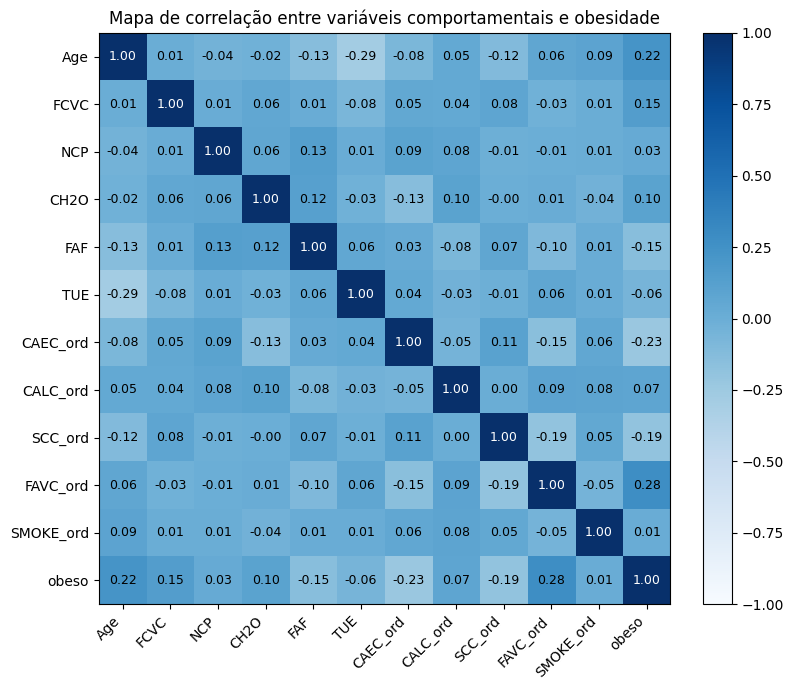

In [13]:
df_corr = df.copy()

ordinal_maps = {
    "CAEC": {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "CALC": {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "SCC": {"no": 0, "yes": 1},
    "FAVC": {"no": 0, "yes": 1},
    "SMOKE": {"no": 0, "yes": 1},
}

for col, mapping in ordinal_maps.items():
    df_corr[col + "_ord"] = df_corr[col].map(mapping)

corr_cols = [
    "Age", "FCVC", "NCP", "CH2O", "FAF", "TUE",
    "CAEC_ord", "CALC_ord", "SCC_ord", "FAVC_ord", "SMOKE_ord",
    "obeso"
]

corr = df_corr[corr_cols].corr()

plt.figure(figsize=(9,7))

# Heatmap em tons de azul
im = plt.imshow(corr, cmap="Blues", vmin=-1, vmax=1)

# Barra de cores
plt.colorbar(im, fraction=0.046, pad=0.04)

# Eixos
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

# Adicionar valores numéricos em cada célula
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center",
            color="black" if abs(corr.iloc[i, j]) < 0.5 else "white",
            fontsize=9
        )

plt.title("Mapa de correlação entre variáveis comportamentais e obesidade")
plt.tight_layout()
plt.show()

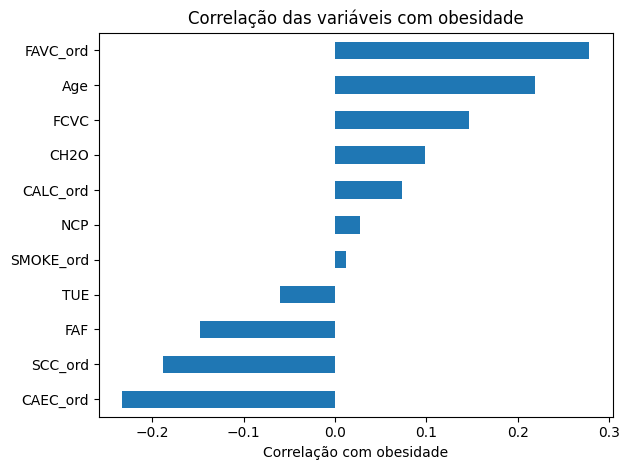

In [14]:
corr_with_target = corr["obeso"].drop("obeso").sort_values()

plt.figure()
corr_with_target.plot(kind="barh")
plt.xlabel("Correlação com obesidade")
plt.title("Correlação das variáveis com obesidade")
plt.tight_layout()
plt.show()


In [15]:
corr_spearman = df_corr[corr_cols].corr(method="spearman")
corr_spearman

,Age,FCVC,NCP,CH2O,FAF,TUE,CAEC_ord,CALC_ord,SCC_ord,FAVC_ord,SMOKE_ord,obeso
Age,1.000000,0.029627,-0.072667,0.023199,-0.197099,-0.293479,-0.122050,0.097255,-0.163181,0.094804,0.076997,0.324901
FCVC,0.029627,1.000000,0.017796,0.051780,0.015001,-0.048996,0.080075,0.059414,0.080659,-0.026551,0.005339,0.152783
NCP,-0.072667,0.017796,1.000000,0.058484,0.143055,0.022967,0.120371,0.075602,-0.012080,-0.014085,0.014972,-0.008522
CH2O,0.023199,0.051780,0.058484,1.000000,0.110882,-0.035387,-0.155921,0.098076,-0.001242,0.014237,-0.036629,0.099624
FAF,-0.197099,0.015001,0.143055,0.110882,1.000000,0.057696,0.015374,-0.079674,0.061725,-0.091487,0.011490,-0.140118
TUE,-0.293479,-0.048996,0.022967,-0.035387,0.057696,1.000000,0.037794,-0.032195,-0.024617,0.064978,0.003645,-0.050474
CAEC_ord,-0.122050,0.080075,0.120371,-0.155921,0.015374,0.037794,1.000000,-0.076480,0.105738,-0.162138,0.052505,-0.250060
CALC_ord,0.097255,0.059414,0.075602,0.098076,-0.079674,-0.032195,-0.076480,1.000000,-0.002317,0.098976,0.076050,0.087148
SCC_ord,-0.163181,0.080659,-0.012080,-0.001242,0.061725,-0.024617,0.105738,-0.002317,1.000000,-0.190658,0.047731,-0.187952
FAVC_ord,0.094804,-0.026551,-0.014085,0.014237,-0.091487,0.064978,-0.162138,0.098976,-0.190658,1.000000,-0.050660,0.278355


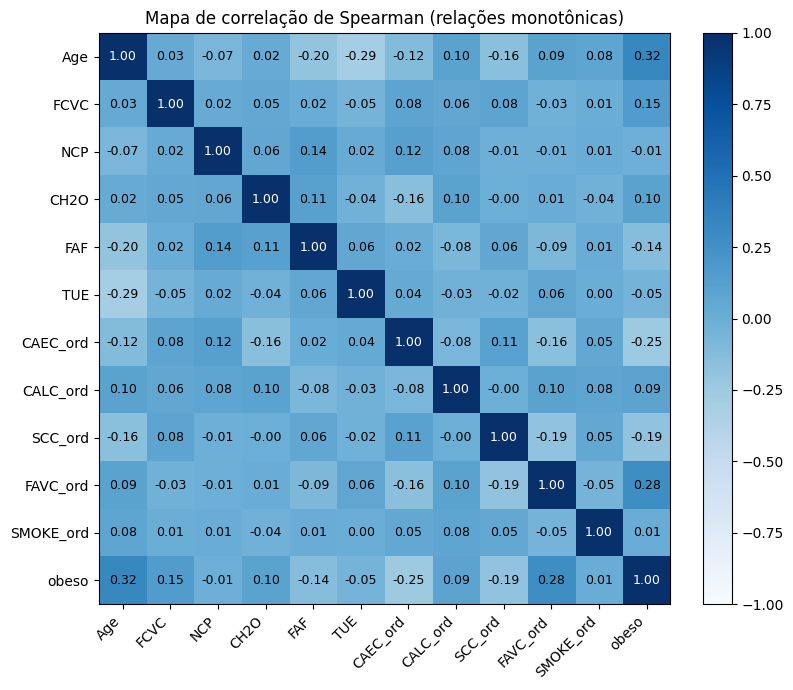

In [16]:
plt.figure(figsize=(9,7))

im = plt.imshow(corr_spearman, cmap="Blues", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

# valores numéricos
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j, i,
            f"{corr_spearman.iloc[i, j]:.2f}",
            ha="center", va="center",
            color="black" if abs(corr_spearman.iloc[i, j]) < 0.5 else "white",
            fontsize=9
        )

plt.title("Mapa de correlação de Spearman (relações monotônicas)")
plt.tight_layout()
plt.show()

In [17]:
df_corr.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,obeso,CAEC_ord,CALC_ord,SCC_ord,FAVC_ord,SMOKE_ord
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.315964,1.701677,86.586058,2.423496,2.687826,2.014685,1.006632,0.664614,0.460445,1.140692,0.731407,0.045476,0.883941,0.020843
std,6.357078,0.093305,26.191172,0.583905,0.809680,0.688616,0.895462,0.674009,0.498551,0.468543,0.515498,0.208395,0.320371,0.142893
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,1.630000,65.473343,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,23.000000,1.700499,83.000000,2.000000,3.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000,1.000000,3.000000,3.000000,1.000000,1.000000,1.000000


### 2.1 Categoria x Obesidade

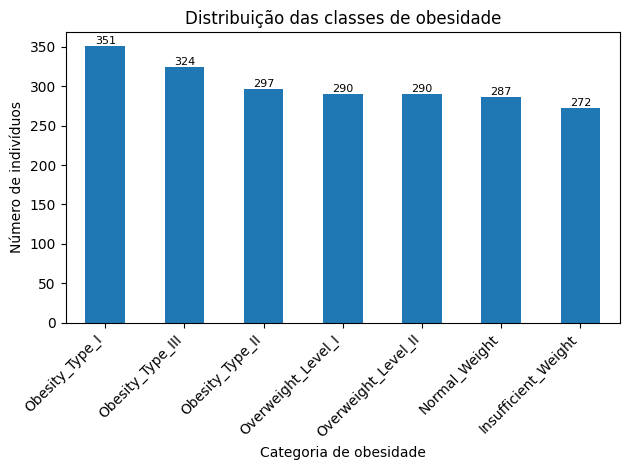

In [18]:
plt.figure()
ax = df["Obesity"].value_counts().plot(kind="bar")
plt.xlabel("Categoria de obesidade")
plt.ylabel("Número de indivíduos")
plt.title("Distribuição das classes de obesidade")
plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    value = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        value,
        value,
        ha="center",
        va="bottom",
        fontsize=8
    )
plt.tight_layout()
plt.show()


### TUE vs Obesidade

TUE — Tempo diário usando dispositivos eletrônicos. Valores (escala 0–2):
- 0 ~0–2 h/dia
- 1 ~3–5 h/dia
- 2 > 5 h/dia.

===

➡️ Não há uma relação direta entre tempo de tela e obesidade, visto que valores 0 e 1 do TUE tem prevalências semelhantes, quanto o TUE=2 tem prevalência menor. Isso já indica que tempo de tela isolado não explica obesidade.

Hipótese: Talvez seja importante fazer uma correlação dessa coluna com idade, pois o tempo de tela pode estar mais relacinado com jovens...

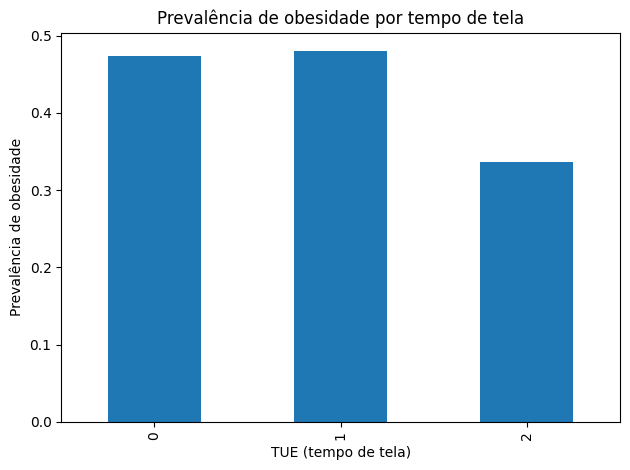

In [19]:
plt.figure()
df.groupby("TUE")["obeso"].mean().plot(kind="bar")
plt.xlabel("TUE (tempo de tela)")
plt.ylabel("Prevalência de obesidade")
plt.title("Prevalência de obesidade por tempo de tela")
plt.tight_layout()
plt.show()

### 2.2 Idade vs Obesidade + TUE (Tempo Usando Eletronicos)

Resultados
- Grupo 0 (não obesos):
  - Mediana entre 20 e 21 anos
  - Distribuição mais concentrada
  - Muitos outliers mais velhos => até 60 anos
  
- Grupo 1 (obesos):
  - Mediana entre 25 e 26 anos
  - Menos outliers extremos, mas mais massa central em idades altas

- Também foi validada a relação de TUE com Age
  - TUE está fortemente associado a idade
  - Indivíduos mais jovens tendem a ficar mais tempo nas telas
  - Logo, o efeito de TUE na obesidade é confundido pela idade (confounding)
    - Jovens:
      - Muito tempo de tela
      - Menor obesidade
    - Adultos
      - Menos tempo de tela
      - Maior obesidade
  - Também foi constatado que TUE não está relacionado com sedentarismo, pois mais tempo de tela está ligado mais a idade do que falta de atividade.

<Figure size 640x480 with 0 Axes>

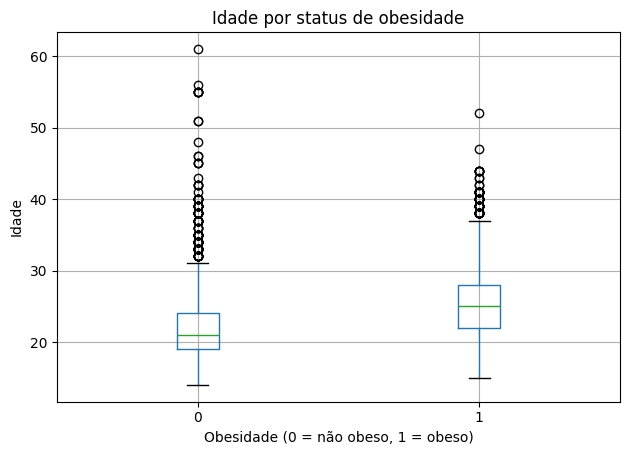

In [20]:
plt.figure()
df.boxplot(column="Age", by="obeso")
plt.xlabel("Obesidade (0 = não obeso, 1 = obeso)")
plt.ylabel("Idade")
plt.title("Idade por status de obesidade")
plt.suptitle("")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

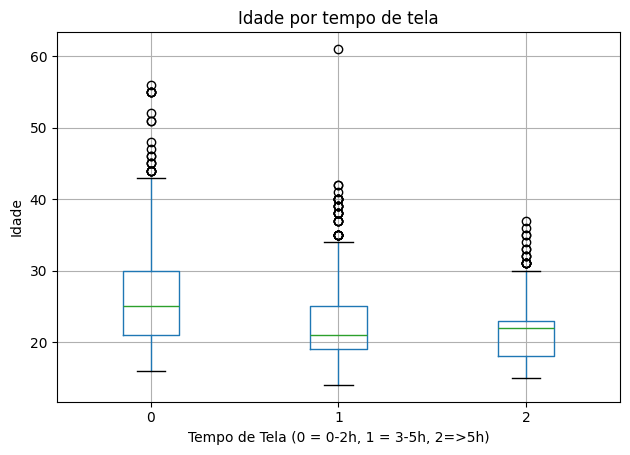

In [21]:
plt.figure()
df.boxplot(column="Age", by="TUE")
plt.xlabel("Tempo de Tela (0 = 0-2h, 1 = 3-5h, 2=>5h)")
plt.ylabel("Idade")
plt.title("Idade por tempo de tela")
plt.suptitle("")
plt.tight_layout()
plt.show()

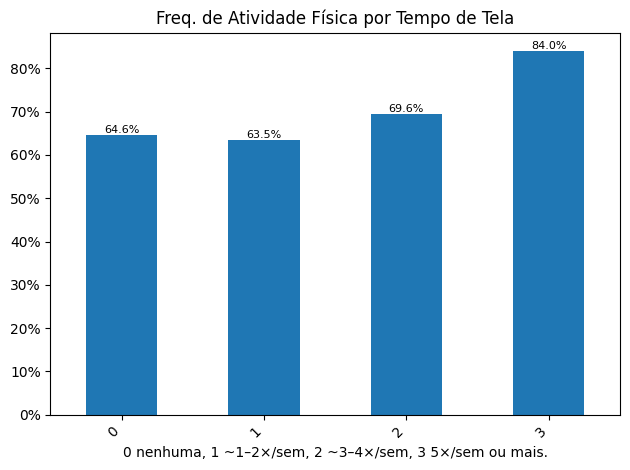

In [40]:
build_plot(
    df,
    groupby="FAF",
    column="TUE",
    title="Freq. de Atividade Física por Tempo de Tela",
    xlabel="0 nenhuma, 1 ~1–2×/sem, 2 ~3–4×/sem, 3 5×/sem ou mais.",
    ylabel=""
)

In [43]:
bins = [0, 18, 25, 30, 40, 100]
df["Age_bin"] = pd.cut(df["Age"], bins=bins, right=True)

prev = (df.groupby(["Age_bin", "TUE"])["obeso"]
          .mean()
          .reset_index(name="prev_obesidade"))
print(prev)


      Age_bin  TUE  prev_obesidade
0     (0, 18]    0        0.263158
1     (0, 18]    1        0.266667
2     (0, 18]    2        0.129032
3    (18, 25]    0        0.320276
4    (18, 25]    1        0.472998
5    (18, 25]    2        0.316901
6    (25, 30]    0        0.771429
7    (25, 30]    1        0.813953
8    (25, 30]    2        0.782609
9    (30, 40]    0        0.543478
10   (30, 40]    1        0.437500
11   (30, 40]    2        0.647059
12  (40, 100]    0        0.625000
13  (40, 100]    1        0.250000
14  (40, 100]    2             NaN


/var/folders/8c/3b04s6s55p1d_3f3ws501zlc0000gn/T/ipykernel_97156/237494368.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prev = (df.groupby(["Age_bin", "TUE"])["obeso"]


In [44]:
counts = (df.groupby(["Age_bin", "TUE"])["obeso"]
            .size()
            .reset_index(name="n"))
print(counts)

      Age_bin  TUE    n
0     (0, 18]    0   76
1     (0, 18]    1  165
2     (0, 18]    2   62
3    (18, 25]    0  434
4    (18, 25]    1  537
5    (18, 25]    2  142
6    (25, 30]    0  210
7    (25, 30]    1  129
8    (25, 30]    2   23
9    (30, 40]    0  184
10   (30, 40]    1   80
11   (30, 40]    2   17
12  (40, 100]    0   48
13  (40, 100]    1    4
14  (40, 100]    2    0


/var/folders/8c/3b04s6s55p1d_3f3ws501zlc0000gn/T/ipykernel_97156/1156295593.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (df.groupby(["Age_bin", "TUE"])["obeso"]


### 2.3 Atividade Física (FAF) vs Obesidade + Idade

FAF: Frequência semanal de atividade física. Valores (escala 0–3):
- 0 nenhuma
- 1 ~1–2×/sem
- 2 ~3–4×/sem
- 3 5×/sem ou mais

===

➡️ No primeiro gráfico (Obesidade vs FAF), percebe-se uma relação inversa entre atividade física e obesidade, pois quanto maior a frequência de atividade física, menor a prevalência de obesidade

Porém, ele sozinho não é determinante, visto que vemos mais de 20% dos obesos tem FAF=3. Terei que validar ele em conjunto com outros fatores.

===

No segundo gráfico, Age x FAF, a correlação negativa (-0.20) ganhou forma visual, onde vemos gradualmente o FAF diminuindo que a idade média vai aumentando
-> Isso significa que a probabilidade média de se exercitar diminui com a idade.

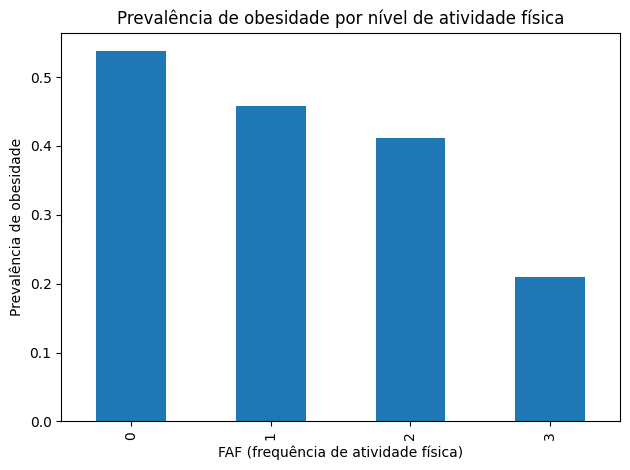

In [23]:
plt.figure()
df.groupby("FAF")["obeso"].mean().plot(kind="bar")
plt.xlabel("FAF (frequência de atividade física)")
plt.ylabel("Prevalência de obesidade")
plt.title("Prevalência de obesidade por nível de atividade física")
plt.tight_layout()
plt.show()


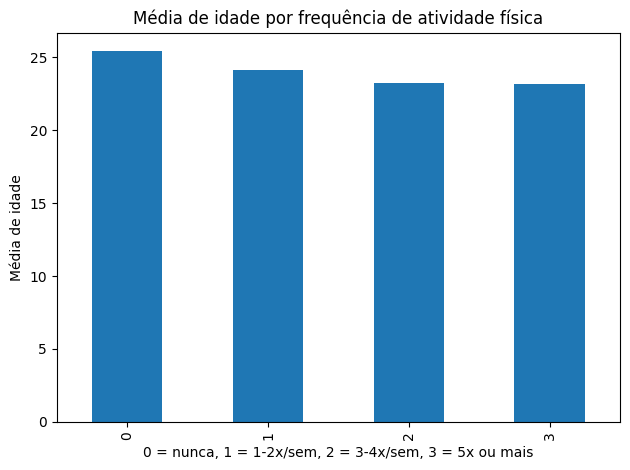

In [24]:
plt.figure()
df.groupby("FAF")["Age"].mean().plot(kind="bar")
plt.xlabel("0 = nunca, 1 = 1-2x/sem, 2 = 3-4x/sem, 3 = 5x ou mais")
plt.ylabel("Média de idade")
plt.title("Média de idade por frequência de atividade física")
plt.tight_layout()
plt.show()


##### 💡 Relação de média de idade x FAF x Obesidade

Notou-se uma queda de obesidade com o aumento de atividade física, sendo muito maior do que a variação de idade média
Parece que o efeito da atividade física sobre obesidade não é explicado apenas pela idade => idade é modulador, não explicação única

Obviamente, um fator que deve ser determinante também é o consumo de alimento (calorias), que precisarei validar a seguir...

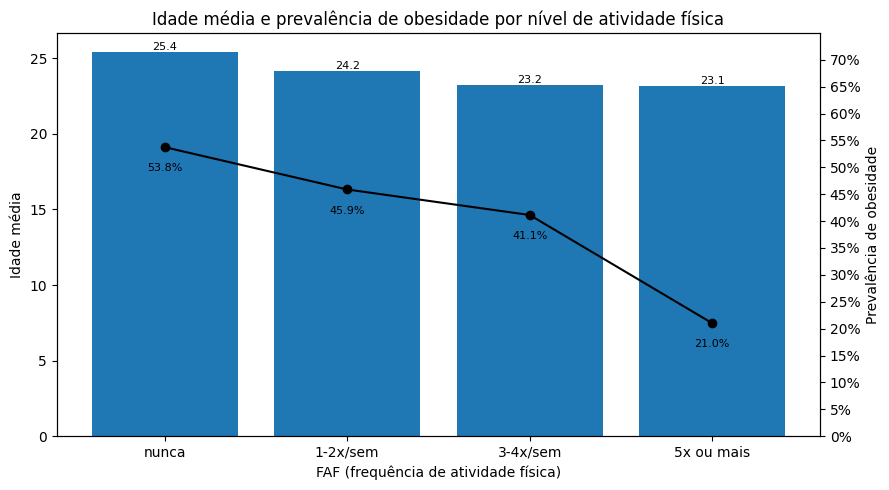

In [25]:
grouped = df.groupby("FAF").agg(mean_age=("Age","mean"), obesity_rate=("obeso","mean")).reset_index()

# Labels textuais para FAF
faf_labels = {
    0: "nunca",
    1: "1-2x/sem",
    2: "3-4x/sem",
    3: "5x ou mais"
}

# Garantir ordem e criar posições categóricas (0..3)
grouped = grouped.sort_values("FAF").copy()
x = np.arange(len(grouped))  # [0,1,2,3]
x_labels = [faf_labels[int(v)] for v in grouped["FAF"]]

fig, ax1 = plt.subplots(figsize=(9,5))

# Barras: idade média (eixo esquerdo)
bars = ax1.bar(x, grouped["mean_age"])
ax1.set_xlabel("FAF (frequência de atividade física)")
ax1.set_ylabel("Idade média")
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels)

# Data labels nas barras (em cima)
for b in bars:
    h = b.get_height()
    ax1.text(
        b.get_x() + b.get_width()/2, h,
        f"{h:.1f}",
        ha="center", va="bottom", fontsize=8
    )

# Linha: prevalência de obesidade (eixo direito)
ax2 = ax1.twinx()
line = ax2.plot(x, grouped["obesity_rate"], marker="o")[0]

ax2.set_ylim(0, 0.75)

ticks = np.arange(0, 0.75, 0.05)
ax2.set_yticks(ticks)
ax2.set_yticklabels([f"{int(t*100)}%" for t in ticks])

ax2.set_ylabel("Prevalência de obesidade")
ax2.tick_params(axis="y", colors="black")

# Cor da linha e dos pontos
line.set_color("black")

# Data labels abaixo dos pontos
for xi, yi in zip(x, grouped["obesity_rate"]):
    ax2.text(
        xi, yi - 0.03, # -0.03 coloca abaixo do ponto
        f"{yi*100:.1f}%",
        ha="center", va="top",
        color="black", fontsize=8
    )

plt.title("Idade média e prevalência de obesidade por nível de atividade física")
plt.tight_layout()
plt.show()


### 2.5 - Consumo de vegetais (FCVC) vs Obesidade

O plot abaixo mostra o que obesos consomem mais vejetais, comprovando o comportamento reativo já encontrado anteriormente nas correlações (consequencia e não causa).

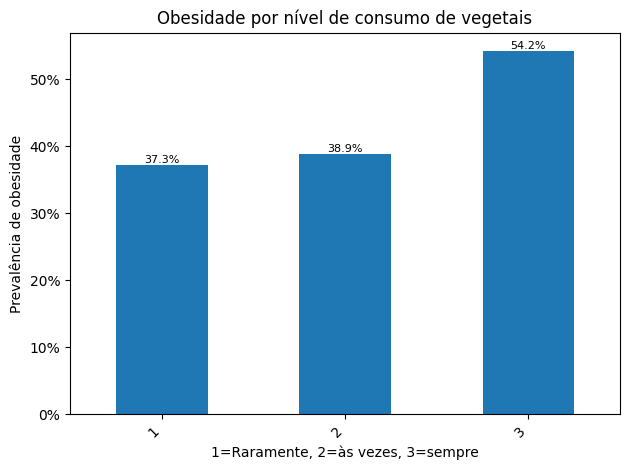

In [26]:
build_plot(
    df,
    groupby="FCVC",
    column="obeso",
    title="Obesidade por nível de consumo de vegetais",
    xlabel="1=Raramente, 2=às vezes, 3=sempre",
    ylabel="Prevalência de obesidade"
)


### ⭐️ FAVC vs Obesidade

**FAVC — Consumo frequente de alimentos muito calóricos. Valores: yes (sim), no (não).**

Aqui vemos uma forte associação com o consumo de alimentos muito calóricos com obesidade, onde mostra que 51% das pessoas que consemem frequentemente alimentos muito calóricos são obesas.

Isso também já havia sido notado nos gráficos de correlação: +0.28


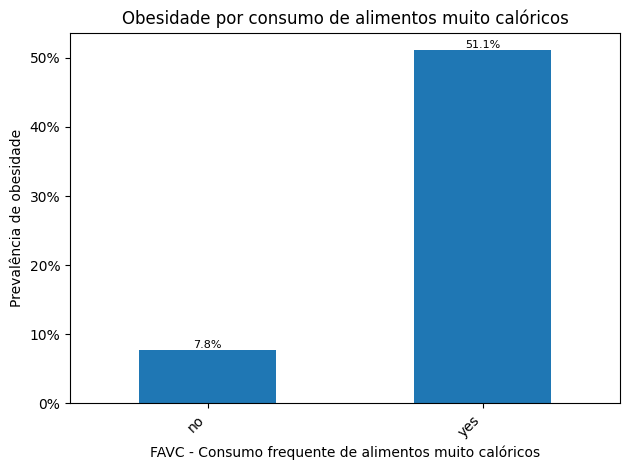

In [27]:
build_plot(
    df,
    groupby="FAVC",
    column="obeso",
    title="Obesidade por consumo de alimentos muito calóricos",
    xlabel="FAVC - Consumo frequente de alimentos muito calóricos",
    ylabel="Prevalência de obesidade"
)

In [28]:
df_corr.groupby("FAVC_ord")["obeso"].agg(
    total="count",
    obese_rate="mean"
)


,total,obese_rate
FAVC_ord,,
0,245,0.077551
1,1866,0.510718


### CAEC (consumo de lanches) vs obesidade

**CAEC — Consumo de lanches/comes entre as refeições**

*Valores: no (não consome), Sometimes (às vezes), Frequently (frequentemente), Always (sempre)*

Diferente do FAVC, essa variável não mede caloria, mas padrão alimentar (como a pessoa divide suas refeições ao longo do dia), logo pode ser perigos usar essa variável para determinar se alguém é obeso ou não.

Por 54% indicar "sometimes", me parece que essa variável deve ser interpretada em conjunto com outras...

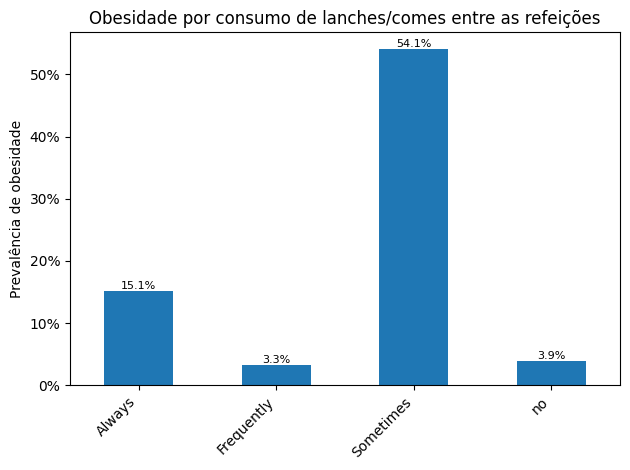

In [29]:
build_plot(
    df,
    groupby="CAEC",
    column="obeso",
    title="Obesidade por consumo de lanches/comes entre as refeições",
    xlabel="",
    ylabel="Prevalência de obesidade"
)

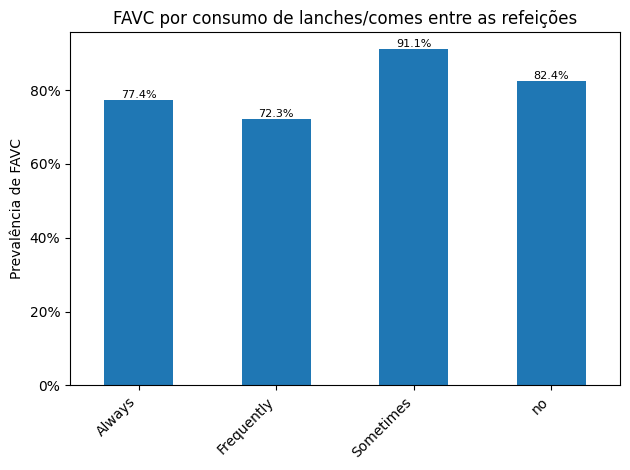

In [30]:
build_plot(
    df_corr,
    groupby="CAEC",
    column="FAVC_ord",
    title="FAVC por consumo de lanches/comes entre as refeições",
    xlabel="",
    ylabel="Prevalência de FAVC"
)

### NCP (refeições principais) vs Obesidade

**NCP — Número de refeições principais por dia**

*Valores (escala 1–4): 1 uma refeição, 2 duas, 3 três, 4 quatro ou mais*

Resumo:
- Obesidade por # de refeições principais aumenta de 1 -> 3, caindo para 6% de 4 ou mais (talvez pessoas que façam dieta?)
- FAVC por # de refeições principais tem pouca variação entre os grupos (todos acima de 84%) ==> NCP não controla ingestão calórica.
- SCC fica "estável" nos 4 grupos.

Conclusão:
- Fracionamento das refeições parecem não estar associado a redução do consumo de alimentos calóricos nem a maior controle de ingestão
- Número de refeições isolados não é um bom indicador


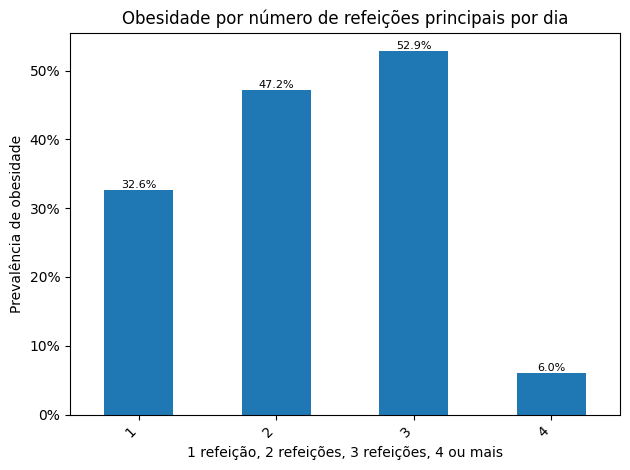

In [31]:
build_plot(
    df,
    groupby="NCP",
    column="obeso",
    title="Obesidade por número de refeições principais por dia",
    xlabel="1 refeição, 2 refeições, 3 refeições, 4 ou mais",
    ylabel="Prevalência de obesidade"
)

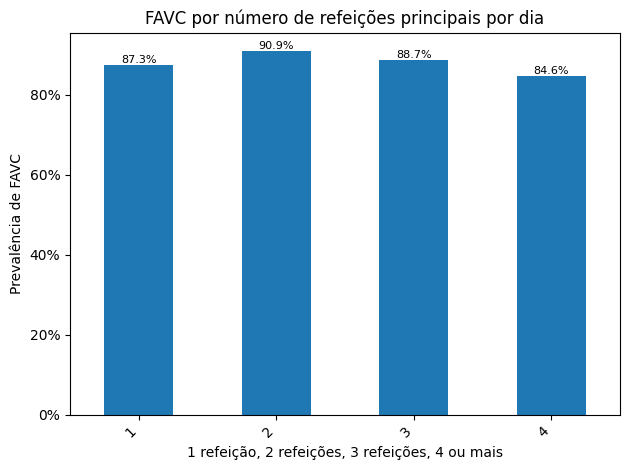

In [32]:
build_plot(
    df_corr,
    groupby="NCP",
    column="FAVC_ord",
    title="FAVC por número de refeições principais por dia",
    xlabel="1 refeição, 2 refeições, 3 refeições, 4 ou mais",
    ylabel="Prevalência de FAVC"
)

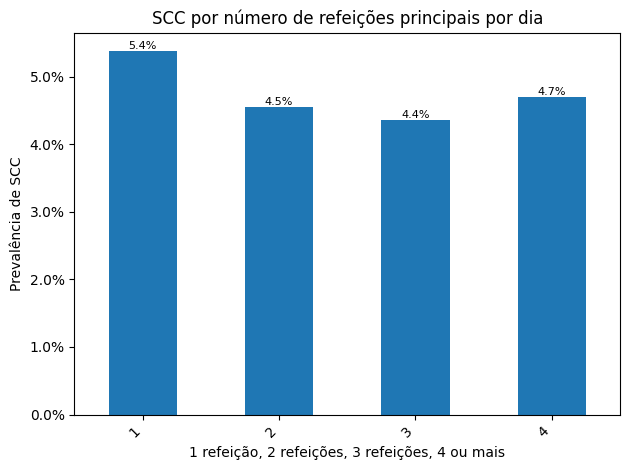

In [33]:
build_plot(
    df_corr,
    groupby="NCP",
    column="SCC_ord",
    title="SCC por número de refeições principais por dia",
    xlabel="1 refeição, 2 refeições, 3 refeições, 4 ou mais",
    ylabel="Prevalência de SCC"
)

In [34]:
# poucas pessoas monitoram a ingestão calórica diária
df_corr["SCC_ord"].value_counts()

SCC_ord
0    2015
1      96
Name: count, dtype: int64

In [35]:
df_ncp_4 = df_corr[df_corr["NCP"]==4]
df_ncp_4

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,...,TUE,CALC,MTRANS,Obesity,obeso,CAEC_ord,CALC_ord,SCC_ord,FAVC_ord,SMOKE_ord
18,Female,30,1.710000,82.000000,yes,yes,3,4,Frequently,yes,...,0,no,Automobile,Overweight_Level_II,0,2,0,0,1,1
25,Male,20,1.600000,50.000000,yes,no,2,4,Frequently,yes,...,2,no,Public_Transportation,Normal_Weight,0,2,0,0,0,1
27,Female,23,1.600000,52.000000,no,yes,2,4,Frequently,no,...,1,Sometimes,Automobile,Normal_Weight,0,2,1,0,1,0
30,Male,29,1.770000,83.000000,no,yes,1,4,Frequently,no,...,1,no,Motorbike,Overweight_Level_I,0,2,0,0,1,0
34,Male,22,1.650000,62.000000,no,yes,2,4,Frequently,no,...,0,Sometimes,Public_Transportation,Normal_Weight,0,2,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1561,Male,31,1.726279,110.714711,yes,yes,2,4,Sometimes,no,...,0,no,Automobile,Obesity_Type_II,1,1,0,0,1,0
1603,Male,24,1.622297,99.982541,yes,yes,3,4,Sometimes,no,...,1,no,Public_Transportation,Obesity_Type_II,1,1,0,0,1,0
1627,Male,40,1.722396,109.349025,yes,yes,2,4,Sometimes,no,...,0,no,Automobile,Obesity_Type_II,1,1,0,0,1,0
1699,Male,40,1.706741,108.012603,yes,yes,2,4,Sometimes,no,...,0,no,Automobile,Obesity_Type_II,1,1,0,0,1,0


### CALC (bebida) vs Obesidade

**CALC — Consumo de bebida alcoólica**

*Valores: no (não bebe), Sometimes (às vezes), Frequently (frequentemente), Always (sempre).*

Resumo:
- "Sometimes" se destaca com 51.3% dos obesos
- Porém, essa métrica engana, pois ela fala em perfil comportamental e não ingestão calórica real

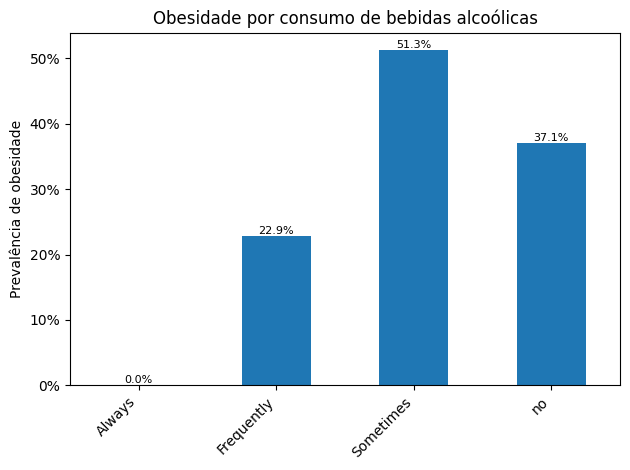

In [36]:
build_plot(
    df,
    groupby="CALC",
    column="obeso",
    title="Obesidade por consumo de bebidas alcoólicas",
    xlabel="",
    ylabel="Prevalência de obesidade"
)

### Family History vs Obesidade

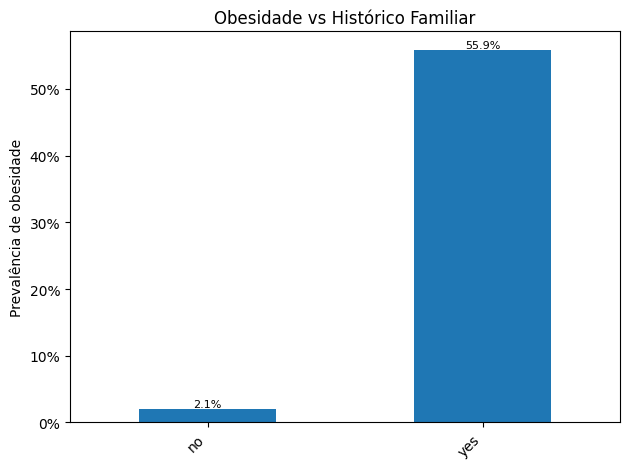

In [37]:
build_plot(
    df,
    groupby="family_history",
    column="obeso",
    title="Obesidade vs Histórico Familiar",
    xlabel="",
    ylabel="Prevalência de obesidade"
)

In [ ]:
build_plot(
    df,
    groupby="MTRANS",
    column="obeso",
    title="Obesidade vs Meio de Transporte",
    xlabel="",
    ylabel="Prevalência de obesidade"
)